In [1]:
# Núcleo y Manipulación de Datos
import pandas as pd
import numpy as np
import time
from pathlib import Path


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de Ensamble
import xgboost as xgb

# Evaluación y Métricas
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if NB_DIR.name != "notebooks" else NB_DIR.parent

data_file = PROJECT_ROOT / "data" / "processed" / "data_prepare_Alzheimer.csv" 

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Archivo:", data_file)


PROJECT_ROOT: /home/jarcos/EpiForecast-MX
Archivo: /home/jarcos/EpiForecast-MX/data/processed/data_prepare_Alzheimer.csv


In [3]:
df =  pd.read_csv(data_file)
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20096 entries, 0 to 20095
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Semana               20096 non-null  int64         
 1   Fecha                20096 non-null  datetime64[ns]
 2   Entidad              20096 non-null  object        
 3   incrementos_hombres  20096 non-null  int64         
 4   incrementos_mujeres  20096 non-null  int64         
 5   Region               20096 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 942.1+ KB


In [4]:
casos = 'incrementos_hombres'

# Se crea la base de datos (df_ts) con índice de tiempo y frecuencia semanal
df_ts = df.copy()
df_ts['Fecha'] = pd.to_datetime(df_ts['Fecha'])
df_ts = df_ts.groupby('Fecha', as_index=False)[casos].sum()
df_ts = df_ts.set_index('Fecha')
df_ts = df_ts.asfreq('W-MON') # Se usa Lunes
df_ts[casos] = df_ts[casos].fillna(0) # Se rellenan huecos

print(f"Datos Univariados (df_ts) listos con {len(df_ts)} filas.")

df_ts.head()

Datos Univariados (df_ts) listos con 626 filas.


,incrementos_hombres
Fecha,
2014-01-06,11.0
2014-01-13,15.0
2014-01-20,11.0
2014-01-27,14.0
2014-02-03,11.0


In [ ]:
df_xg = df_ts.copy()

window = 4
df_xg['Lag_1'] = df_xg[casos].shift(1)
df_xg['Lag_2'] = df_xg[casos].shift(2)
df_xg['Lag_3'] = df_xg[casos].shift(3)
df_xg['Lag_4'] = df_xg[casos].shift(4)
df_xg['Media_Movil_4'] = df_xg[casos].rolling(window=window).mean()
df_xg['Std_Movil_4'] = df_xg[casos].rolling(window=window).std()

df_xg = df_xg.fillna(0)

df_xg.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 626 entries, 2014-01-06 to 2025-12-29
Freq: W-MON
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   incrementos_hombres  626 non-null    float64
 1   Lag_1                626 non-null    float64
 2   Lag_2                626 non-null    float64
 3   Lag_3                626 non-null    float64
 4   Lag_4                626 non-null    float64
 5   Media_Movil_4        626 non-null    float64
 6   Std_Movil_4          626 non-null    float64
dtypes: float64(7)
memory usage: 39.1 KB


In [6]:
split_idx = int(len(df_xg) * 0.8)

train_ts = df_ts[:split_idx].copy()
test_ts  = df_ts[split_idx:].copy()

test_start_date = test_ts.index[0]

train_fe = df_xg[df_xg.index < test_start_date].copy()
test_fe  = df_xg[df_xg.index >= test_start_date].copy()

X_train = train_fe.drop(casos, axis=1)
y_train = train_fe[casos]
X_test = test_fe.drop(casos, axis=1)
y_test = test_fe[casos]


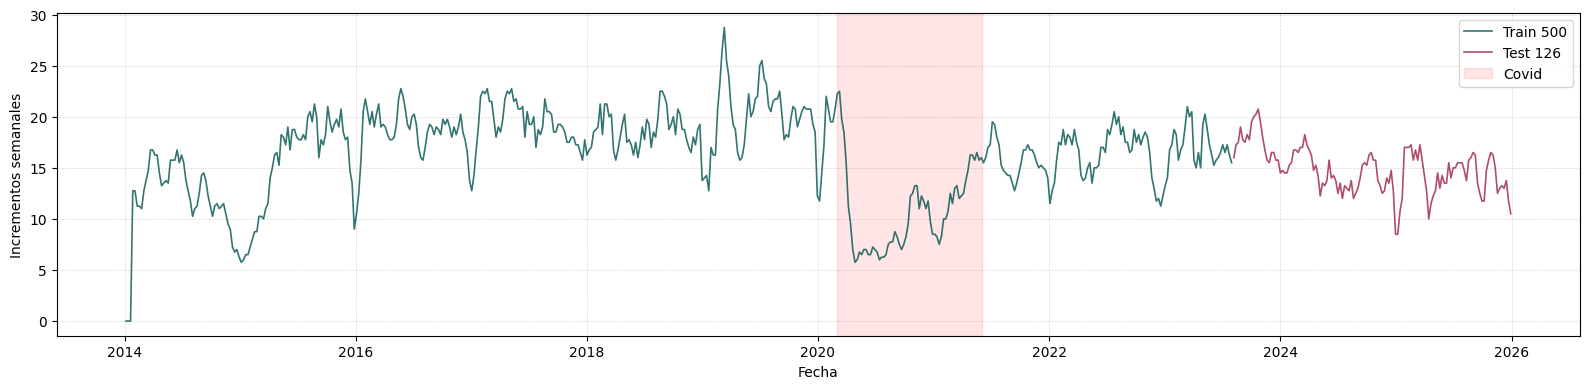

In [7]:
serie_train = X_train.groupby("Fecha")[['Media_Movil_4']].sum()
serie_test = X_test.groupby("Fecha")[['Media_Movil_4']].sum()


plt.figure(figsize=(16,4))
        
plt.plot(serie_train.index,serie_train['Media_Movil_4'],
                 linewidth=1.2, alpha=0.8, color="#00524E" , label=f'Train {len(X_train)}')

plt.plot(serie_test.index,serie_test['Media_Movil_4'],
                 linewidth=1.2, alpha=0.8, color="#9B2242" , label=f'Test {len(X_test)}')

try:
    covid_start = pd.Timestamp("2020-03-01")
    covid_end = pd.Timestamp("2021-06-01")
    plt.axvspan(covid_start, covid_end, alpha=0.1, color="red", label="Covid")
except Exception:
    pass

plt.xlabel("Fecha")
plt.ylabel("Incrementos semanales")
plt.legend(fontsize=10)
plt.tight_layout()
plt.grid(True,color="gray", alpha=0.3, linestyle="--",linewidth=0.5)
plt.show()


In [8]:
results_summary = {} # Se inicializa el diccionario

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid_xgb = {
    'n_estimators': [300, 500, 1000],  # Número de árboles
    'max_depth': [3, 5, 7],            # Profundidad máxima
    'learning_rate': [0.01, 0.1],    # Tasa de aprendizaje
    'subsample': [0.7, 1.0]            # Fracción de datos a usar por cada árbol
}

tscv = TimeSeriesSplit(n_splits=3)

# Se configura el GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,  # Usar todos los procesadores
    verbose=2
)

In [9]:

start_time_xgb_opt = time.time()

grid_search_xgb.fit(X_train, y_train)

optimization_time_xgb = time.time() - start_time_xgb_opt # <--- Mide el tiempo TOTAL

print(f"\nMejores parámetros encontrados para XGBoost: {grid_search_xgb.best_params_}")
print(f"Tiempo de Optimización (GridSearch): {optimization_time_xgb:.2f} segundos") # <--- Los 219s

# --- Re-entrenamiento del mejor modelo para un tiempo justo ---
print("\nEntrenando el modelo final UNA VEZ con los mejores parámetros...")

# Se crea un nuevo modelo con los mejores parámetros encontrados
best_xgb_params = grid_search_xgb.best_params_
final_xgb_model = xgb.XGBRegressor(objective='reg:squarederror', 
                                   random_state=42, 
                                   **best_xgb_params)

start_time_xgb_train = time.time() # <--- Inicia el cronómetro de ENTRENAMIENTO
final_xgb_model.fit(X_train, y_train)
training_time_xgb = time.time() - start_time_xgb_train # <--- Mide el tiempo de UN solo fit

print(f"Tiempo de Entrenamiento (un solo fit): {training_time_xgb:.2f} segundos") # <--- El tiempo rápido y justo

# Se evalúa el mejor modelo
y_pred_xgb = final_xgb_model.predict(X_test)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0; total time=   1.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0; total time=   1.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=1.0; total time=   1.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.7; total time=   1.3s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=1.0; total time=   1.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=300, subsample=0.7; total time=   1.4s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.7; total time=   1.3

In [10]:
# Se calculan las métricas
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape_xgb = 100 * np.mean(2 * np.abs(y_pred_xgb - y_test) / (np.abs(y_test) + np.abs(y_pred_xgb) + 1e-8))


print("\nMétricas de XGBoost")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")


Métricas de XGBoost
MAE:  0.75
RMSE: 1.06
MAPE: 7.28%


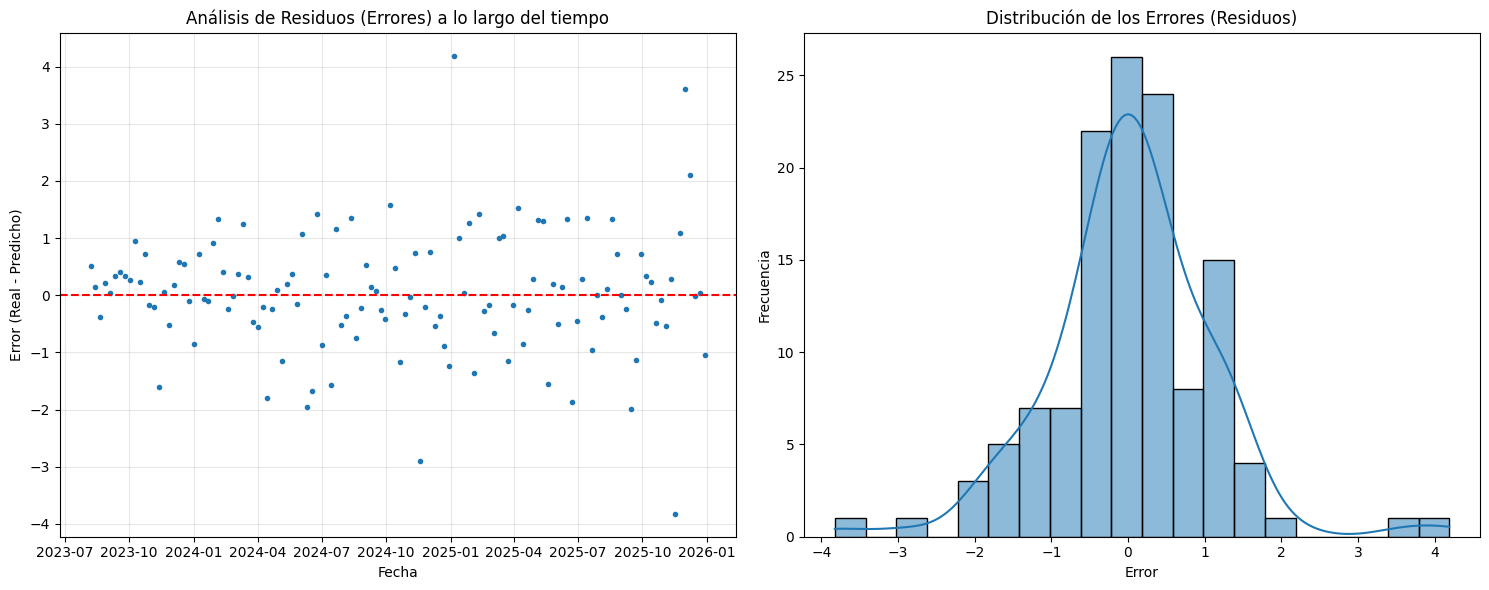

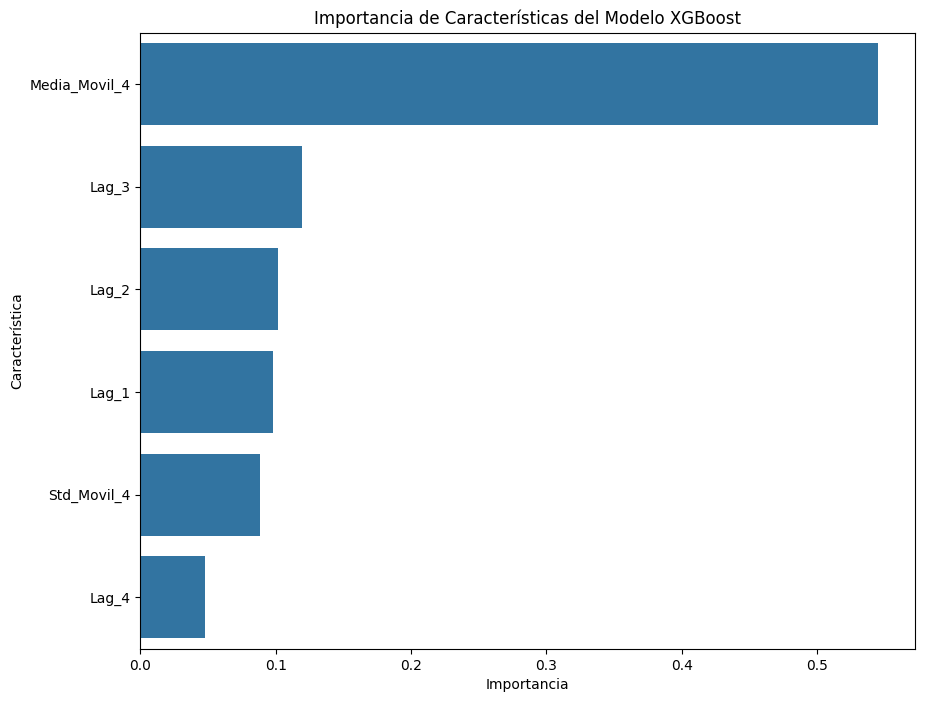

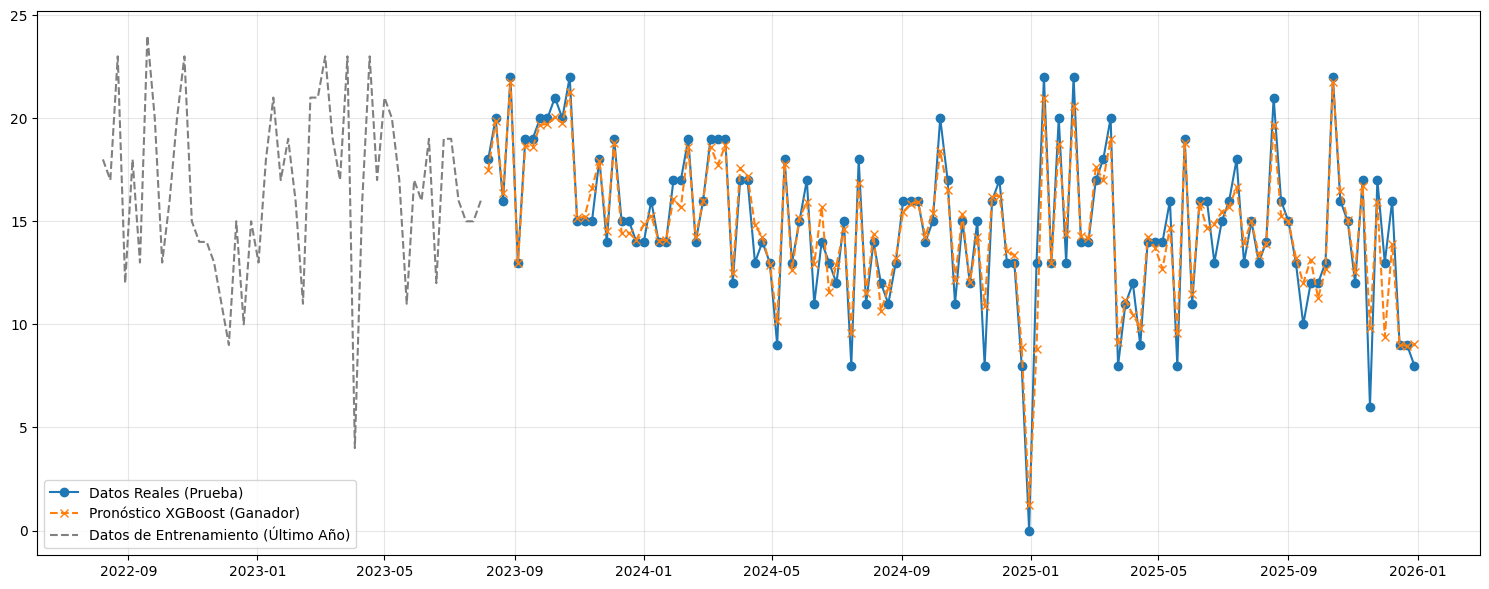

In [11]:
residuos_xgb = y_test - y_pred_xgb

plt.figure(figsize=(15, 6))

# Gráfico de Residuos a lo largo del tiempo
plt.subplot(1, 2, 1)
plt.plot(test_fe.index, residuos_xgb, marker='.', linestyle='None')
plt.axhline(0, color='red', linestyle='--')
plt.title('Análisis de Residuos (Errores) a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Error (Real - Predicho)')
plt.grid(True, alpha=0.3)

# Histograma de Residuos
plt.subplot(1, 2, 2)
sns.histplot(residuos_xgb, kde=True)
plt.title('Distribución de los Errores (Residuos)')
plt.xlabel('Error')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# --- Gráfico de Importancia de Características ---
# Este gráfico nos dice qué variables consideró más importantes el XGBoost.
plt.figure(figsize=(10, 8))
# Se obtienen las importancias
importancias = final_xgb_model.feature_importances_
# Se crea un DataFrame para graficar
feature_names = X_train.columns
importancia_df = pd.DataFrame({'Característica': feature_names, 'Importancia': importancias})
importancia_df.sort_values(by='Importancia', ascending=False, inplace=True)

# Se grafica
sns.barplot(x='Importancia', y='Característica', data=importancia_df)
plt.title('Importancia de Características del Modelo XGBoost')
plt.show()


# --- Gráfico de Tendencia y Predicción ---
# (Este es el gráfico de evaluación que ya habíamos planeado)
plt.figure(figsize=(15, 6))
plt.plot(test_fe.index, y_test, 'o-', label='Datos Reales (Prueba)')
plt.plot(test_fe.index, y_pred_xgb, 'x--', label='Pronóstico XGBoost (Ganador)')
plt.plot(train_fe.index[-52:], train_fe[casos][-52:], label='Datos de Entrenamiento (Último Año)', color='gray', linestyle='--')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()